# D7 on D4: Focal Loss + Class Weights under Label Noise (v2)
## Benchmarking Noise-Robust Training Strategies for Liver Tumor Segmentation on LiTS

**Group:** 7 | **Members:** 26100098, 26100392

**Strategy under test:** D4 — 2D U-Net (stack=1) + Dice + Focal Loss (alpha=class_weights, gamma=2.0)



## 1. Noise Configuration — EDIT BETWEEN RUNS

In [1]:


NOISE_TYPE = 'combined'    # 'missing' | 'jitter' | 'combined' | None
NOISE_RATE = 0.50          # 0.20, 0.50, 0.70   

STRATEGY     = 'D4'
NOISE_SEED   = 2026        
RESULTS_FILE = f'results_d7_{STRATEGY}.json'

config_tag = (
    f'{STRATEGY}__clean' if NOISE_TYPE is None
    else f'{STRATEGY}__{NOISE_TYPE}_r{int(round(NOISE_RATE*100)):02d}'
)
print(f'Strategy:    {STRATEGY}')
print(f'Noise type:  {NOISE_TYPE}')
print(f'Noise rate:  {NOISE_RATE if NOISE_TYPE else 0}')
print(f'Config tag:  {config_tag}')
print(f'Results file:{RESULTS_FILE}')


Strategy:    D4
Noise type:  combined
Noise rate:  0.5
Config tag:  D4__combined_r50
Results file:results_d7_D4.json


## 2. Imports

In [2]:
import os, sys, json, time, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

sys.path.insert(0, '.')
from lits_core import (
    get_device,
    load_lits_paths,
    make_split,
    LiTS25DDataset,
    UNet2D,
    dice_loss,
    compute_dice_per_class,
)

DEVICE = get_device()
print(f'Device:   {DEVICE}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f'PyTorch:  {torch.__version__}')


Device:   mps
PyTorch:  2.11.0


## 3. Configuration


In [3]:
DATA_DIR = '/Users/aemanadnan/Desktop/DL proj/archive-2'

IMG_SIZE       = 128
BATCH_SIZE     = 16
NUM_EPOCHS     = 20
LR             = 1e-4
HU_MIN, HU_MAX = -100, 400
STACK_SIZE     = 1  

print(f'Data:        {DATA_DIR}')
print(f'Img size:    {IMG_SIZE}')
print(f'Batch size:  {BATCH_SIZE}')
print(f'Epochs:      {NUM_EPOCHS}')
print(f'LR:          {LR}')
print(f'Stack size:  {STACK_SIZE} (pure 2D)')


Data:        /Users/aemanadnan/Desktop/DL proj/archive-2
Img size:    128
Batch size:  16
Epochs:      20
LR:          0.0001
Stack size:  1 (pure 2D)


## 4. Load Volumes and Split

Same `seed=42` 70/15/15 volume-level split as every other D-experiment. Identical patients across strategies — that's the controlled-variable design.


In [4]:
volume_paths, seg_paths = load_lits_paths(DATA_DIR)

train_v, train_s, val_v, val_s, test_v, test_s = make_split(
    volume_paths, seg_paths, seed=SEED, train_frac=0.70, val_frac=0.15
)


Found 51 matched volume-segmentation pairs
Split — Train: 35 | Val: 8 | Test: 8


## 5. Build Datasets — Train Gets Noise, Val Stays Clean

`lits_core.LiTS25DDataset` accepts `noise_type` and `noise_rate` directly. We pass them to `train_dataset` only. `val_dataset` always uses `noise_type=None` so evaluation is on clean labels.


In [5]:
print('Building train dataset...')
train_dataset = LiTS25DDataset(
    train_v, train_s,
    img_size=IMG_SIZE, hu_min=HU_MIN, hu_max=HU_MAX,
    stack_size=STACK_SIZE,
    augment=False,            
    noise_type=NOISE_TYPE,
    noise_rate=NOISE_RATE if NOISE_TYPE else 0.0,
    noise_seed=NOISE_SEED,
)

print('\nBuilding val dataset (always clean)...')
val_dataset = LiTS25DDataset(
    val_v, val_s,
    img_size=IMG_SIZE, hu_min=HU_MIN, hu_max=HU_MAX,
    stack_size=STACK_SIZE,
    augment=False,
    noise_type=None,         
    noise_rate=0.0,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f'\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)}')


Building train dataset...
Dataset: 4614 slices | stack=1 | augment=False (medium) | noise=combined@50% (2265 slices)

Building val dataset (always clean)...
Dataset: 1116 slices | stack=1 | augment=False (medium) | noise=None@0% (0 slices)

Train batches: 289 | Val batches: 70


## 6. Sanity Check — Visualize Slices That ACTUALLY Got Noise

The previous wrapper version had a bug where 50% noise on 1-component slices became 0% noise. With slice-level noise, we can directly query which slices were chosen for corruption (`train_dataset._noisy_mask`) and visualize those.


Slices marked noisy: 2265 / 4614 (49.1%)
Dataset: 4614 slices | stack=1 | augment=False (medium) | noise=None@0% (0 slices)


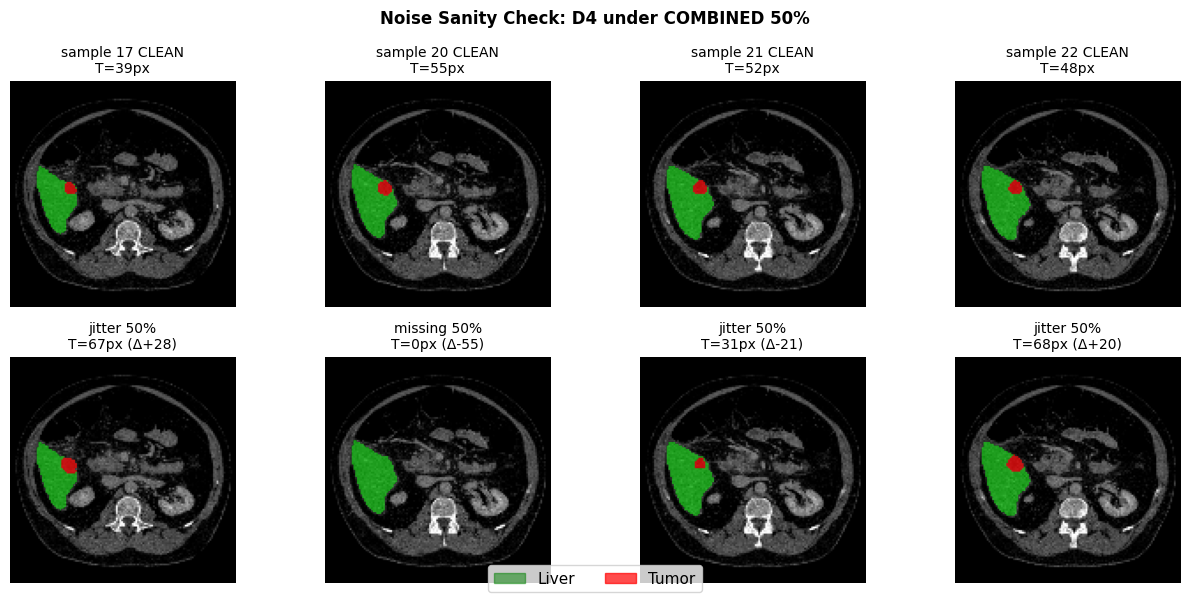

In [6]:
if NOISE_TYPE is None:
    print('Clean run — no noise to visualize.')
else:
    noisy_idxs = np.where(train_dataset._noisy_mask)[0]
    print(f'Slices marked noisy: {len(noisy_idxs)} / {len(train_dataset)} '
          f'({100*len(noisy_idxs)/len(train_dataset):.1f}%)')

    clean_dataset = LiTS25DDataset(
        train_v, train_s,
        img_size=IMG_SIZE, hu_min=HU_MIN, hu_max=HU_MAX,
        stack_size=STACK_SIZE, augment=False,
        noise_type=None, noise_rate=0.0,
    )

    show = []
    for i in noisy_idxs:
        _, m_clean = clean_dataset[int(i)]
        if (m_clean == 2).sum().item() > 30:
            show.append(int(i))
        if len(show) >= 4:
            break

    if not show:
        print('No noisy slices with > 30 tumor pixels — try a higher rate.')
    else:
        fig, axes = plt.subplots(2, len(show), figsize=(3.2 * len(show), 6))
        if len(show) == 1:
            axes = axes[:, None]
        for col, i in enumerate(show):
            ct, m_clean = clean_dataset[i]
            ct_img = ct[0].numpy()             # stack_size=1 -> first channel
            m_clean_np = m_clean.numpy()
            _, m_noisy = train_dataset[i]
            m_noisy_np = m_noisy.numpy()

            # CLEAN
            ov = np.zeros((*ct_img.shape, 4))
            ov[m_clean_np == 1] = [0, 1, 0, 0.5]
            ov[m_clean_np == 2] = [1, 0, 0, 0.7]
            axes[0, col].imshow(ct_img.T, cmap='gray', origin='lower')
            axes[0, col].imshow(ov.transpose(1, 0, 2), origin='lower')
            t_px_c = (m_clean_np == 2).sum()
            axes[0, col].set_title(f'sample {i} CLEAN\nT={t_px_c}px', fontsize=10)
            axes[0, col].axis('off')

            # NOISY
            ov = np.zeros((*ct_img.shape, 4))
            ov[m_noisy_np == 1] = [0, 1, 0, 0.5]
            ov[m_noisy_np == 2] = [1, 0, 0, 0.7]
            axes[1, col].imshow(ct_img.T, cmap='gray', origin='lower')
            axes[1, col].imshow(ov.transpose(1, 0, 2), origin='lower')
            t_px_n = (m_noisy_np == 2).sum()
            delta = int(t_px_n - t_px_c)
            kind = train_dataset._noisy_kinds[i] if NOISE_TYPE == 'combined' else NOISE_TYPE
            axes[1, col].set_title(
                f'{kind} {NOISE_RATE:.0%}\nT={t_px_n}px (Δ{delta:+d})',
                fontsize=10,
            )
            axes[1, col].axis('off')

        green_patch = mpatches.Patch(color='green', alpha=0.5, label='Liver')
        red_patch   = mpatches.Patch(color='red',   alpha=0.7, label='Tumor')
        fig.legend(handles=[green_patch, red_patch], loc='lower center', ncol=2, fontsize=11)
        plt.suptitle(f'Noise Sanity Check: {STRATEGY} under {NOISE_TYPE.upper()} {NOISE_RATE:.0%}',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()


## 7. Build U-Net

Standard 2D U-Net from `lits_core`, configured for D4 (in_channels=1, no attention).


In [7]:
model = UNet2D(in_channels=STACK_SIZE, num_classes=3, base_features=64,
               use_attention=False).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')


Model parameters: 31,036,611


## 8. Loss — Dice + Focal (capped class weights)

D4's signature: `combined_loss = dice_loss + focal_loss(alpha=capped_class_weights, gamma=2.0)`.



In [8]:
def compute_class_weights(dataset, num_classes=3, sample_frac=0.2, max_ratio=5.0):
    """
    Inverse-frequency class weights, capped at max_ratio:1 so tumor doesn't
    explode gradients. Identical to your D4 capped-weights logic.
    """
    counts = np.zeros(num_classes, dtype=np.float64)
    n = len(dataset)
    sample_size = max(1, int(n * sample_frac))
    sample_idxs = np.random.choice(n, size=sample_size, replace=False)
    for i in sample_idxs:
        _, seg = dataset[i]
        for c in range(num_classes):
            counts[c] += (seg == c).sum().item()

    freq    = counts / counts.sum()
    raw     = 1.0 / (freq + 1e-8)
    raw     = np.clip(raw, raw.min(), raw.min() * max_ratio)
    weights = raw / raw.sum() * num_classes

    print(f'Class pixel counts:        {counts}')
    print(f'Class frequencies:         {freq}')
    print(f'Capped weights (max {max_ratio}:1): {weights}')
    return torch.tensor(weights, dtype=torch.float32)


class FocalLoss(nn.Module):
    """Focal Loss = -alpha * (1 - p_t)^gamma * log(p_t)."""
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce    = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt    = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        return focal.mean()


print('Computing class weights from training set (noisy)...')
class_weights = compute_class_weights(train_dataset).to(DEVICE)
focal_fn = FocalLoss(alpha=class_weights, gamma=2.0)


def d4_loss(preds, targets):
    """Dice + Focal — D4's signature combined loss."""
    return dice_loss(preds, targets) + focal_fn(preds, targets)


print('Loss: Dice + Focal (alpha=capped_class_weights, gamma=2.0)')


Computing class weights from training set (noisy)...
Class pixel counts:        [14172991.   906742.    26315.]
Class frequencies:         [0.93823289 0.0600251  0.00174202]
Capped weights (max 5.0:1): [0.27272727 1.36363636 1.36363636]
Loss: Dice + Focal (alpha=capped_class_weights, gamma=2.0)


## 9. Training



In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=4, factor=0.5
)

history = {
    'train_loss': [], 'val_loss': [],
    'val_liver_dice': [], 'val_tumor_dice': [],
    'epoch_mins': [],
}
best_tumor_dice = 0.0
best_liver_at_best_tumor = 0.0
best_epoch = 0
best_state = None

print('=' * 78)
print(f'D7 TRAINING — {config_tag}')
print(f'Epochs: {NUM_EPOCHS} | Batch: {BATCH_SIZE} | Device: {DEVICE}')
print(f'Loss: Dice + Focal (alpha=class_weights, gamma=2.0)')
print('=' * 78)

run_start = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    model.train()
    train_losses = []
    for bi, (ct, seg) in enumerate(train_loader):
        ct, seg = ct.to(DEVICE), seg.to(DEVICE)
        optimizer.zero_grad()
        preds = model(ct)
        loss = d4_loss(preds, seg)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        if (bi + 1) % 100 == 0:
            print(f'  Ep {epoch:02d} batch {bi+1}/{len(train_loader)} loss={loss.item():.4f}')

    # Validation on CLEAN labels
    model.eval()
    val_losses, livers, tumors = [], [], []
    with torch.no_grad():
        for ct, seg in val_loader:
            ct, seg = ct.to(DEVICE), seg.to(DEVICE)
            preds = model(ct)
            val_losses.append(d4_loss(preds, seg).item())
            d = compute_dice_per_class(preds, seg)
            livers.append(d[1])
            tumors.append(d[2])

    m_train = float(np.mean(train_losses))
    m_val   = float(np.mean(val_losses))
    m_liver = float(np.mean(livers))
    m_tumor = float(np.mean(tumors))
    em = (time.time() - t0) / 60

    for k, v in [('train_loss', m_train), ('val_loss', m_val),
                 ('val_liver_dice', m_liver), ('val_tumor_dice', m_tumor),
                 ('epoch_mins', em)]:
        history[k].append(v)

    scheduler.step(m_tumor)
    flag = ''
    if m_tumor > best_tumor_dice:
        best_tumor_dice = m_tumor
        best_liver_at_best_tumor = m_liver
        best_epoch = epoch
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        flag = ' *** BEST'

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | {em:4.1f}min | '
          f'Train: {m_train:.4f} | Val: {m_val:.4f} | '
          f'Liver: {m_liver:.4f} | Tumor: {m_tumor:.4f}{flag}')

run_mins = (time.time() - run_start) / 60
print(f'\nTotal training time: {run_mins:.1f} min')
print(f'Best tumor Dice: {best_tumor_dice:.4f} @ epoch {best_epoch} '
      f'(liver at that epoch: {best_liver_at_best_tumor:.4f})')

ckpt_name = f'best_{config_tag}.pth'
torch.save(best_state, ckpt_name)
print(f'Checkpoint: {ckpt_name}')


D7 TRAINING — D4__combined_r50
Epochs: 20 | Batch: 16 | Device: mps
Loss: Dice + Focal (alpha=class_weights, gamma=2.0)
  Ep 01 batch 100/289 loss=0.5313
  Ep 01 batch 200/289 loss=0.4924
Epoch 01/20 |  8.6min | Train: 0.5345 | Val: 0.4884 | Liver: 0.8562 | Tumor: 0.2255 *** BEST
  Ep 02 batch 100/289 loss=0.3997
  Ep 02 batch 200/289 loss=0.3792
Epoch 02/20 |  8.2min | Train: 0.4065 | Val: 0.4354 | Liver: 0.8770 | Tumor: 0.2215
  Ep 03 batch 100/289 loss=0.3055
  Ep 03 batch 200/289 loss=0.2245
Epoch 03/20 |  8.2min | Train: 0.3172 | Val: 0.4103 | Liver: 0.8645 | Tumor: 0.4968 *** BEST
  Ep 04 batch 100/289 loss=0.2584
  Ep 04 batch 200/289 loss=0.2371
Epoch 04/20 |  8.3min | Train: 0.2415 | Val: 0.4090 | Liver: 0.8713 | Tumor: 0.5057 *** BEST
  Ep 05 batch 100/289 loss=0.3689
  Ep 05 batch 200/289 loss=0.3784
Epoch 05/20 | 10.3min | Train: 0.2172 | Val: 0.4036 | Liver: 0.8788 | Tumor: 0.4443
  Ep 06 batch 100/289 loss=0.1195
  Ep 06 batch 200/289 loss=0.1972
Epoch 06/20 |  8.1min | T

## 10. Save Result 


In [10]:
results_path = Path(RESULTS_FILE)
results = {}
if results_path.exists():
    with results_path.open() as f:
        results = json.load(f)

results[config_tag] = {
    'strategy':    STRATEGY,
    'noise_type':  NOISE_TYPE,
    'noise_rate':  NOISE_RATE if NOISE_TYPE else 0.0,
    'noise_seed':  NOISE_SEED,
    'liver_dice':  best_liver_at_best_tumor,
    'tumor_dice':  best_tumor_dice,
    'best_epoch':  best_epoch,
    'history':     history,
    'num_epochs':  NUM_EPOCHS,
    'run_minutes': float(run_mins),
}

with results_path.open('w') as f:
    json.dump(results, f, indent=2, default=str)

print(f'Saved {config_tag} to {RESULTS_FILE}\n')
print(f'All entries currently in {RESULTS_FILE}:')
for k, v in sorted(results.items()):
    print(f'  {k:30s}  liver={v["liver_dice"]:.4f}  tumor={v["tumor_dice"]:.4f}  '
          f'epoch={v["best_epoch"]}')


Saved D4__combined_r50 to results_d7_D4.json

All entries currently in results_d7_D4.json:
  D4__combined_r50                liver=0.8713  tumor=0.5057  epoch=4


## 11. Plot Degradation Curve



In [11]:
D4_CLEAN_LIVER = 0.8901
D4_CLEAN_TUMOR = 0.4961

with results_path.open() as f:
    results = json.load(f)

if NOISE_TYPE is None:
    print('Clean run — no degradation curve to plot.')
else:
    matching = [v for v in results.values()
                if v.get('strategy') == STRATEGY
                and v.get('noise_type') == NOISE_TYPE]

    if len(matching) < 2:
        print(f'Only {len(matching)} entries for {STRATEGY} x {NOISE_TYPE}; need >=2.')
    else:
        points = [(0.0, D4_CLEAN_LIVER, D4_CLEAN_TUMOR)]
        for e in sorted(matching, key=lambda x: x['noise_rate']):
            points.append((e['noise_rate'], e['liver_dice'], e['tumor_dice']))

        rates = [p[0] for p in points]
        liver = [p[1] for p in points]
        tumor = [p[2] for p in points]

        fig, ax = plt.subplots(figsize=(7.5, 4.8))
        ax.plot(rates, liver, 'o-', color='#2a9d8f', linewidth=2, markersize=9, label='Liver')
        ax.plot(rates, tumor, 's-', color='#e63946', linewidth=2, markersize=9, label='Tumor')
        for r, l, t in zip(rates, liver, tumor):
            ax.annotate(f'{l:.3f}', (r, l), textcoords='offset points', xytext=(0, 8),
                        ha='center', fontsize=9, color='#2a9d8f')
            ax.annotate(f'{t:.3f}', (r, t), textcoords='offset points', xytext=(0, -15),
                        ha='center', fontsize=9, color='#e63946')
        ax.set_xlabel(f'{NOISE_TYPE} noise rate', fontsize=11)
        ax.set_ylabel('Validation Dice (clean labels)', fontsize=11)
        ax.set_title(f'D7: {STRATEGY} degradation under {NOISE_TYPE.upper()} noise',
                     fontsize=12, fontweight='bold')
        ax.set_xticks(rates)
        ax.set_xticklabels([f'{r:.0%}' for r in rates])
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)
        ax.legend(loc='lower left')
        plt.tight_layout()
        out_png = f'd7_{STRATEGY}_{NOISE_TYPE}_curve.png'
        plt.savefig(out_png, dpi=130)
        plt.show()
        print(f'Saved {out_png}')


Only 1 entries for D4 x combined; need >=2.
